In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)


2.21.0


In [6]:
df = pd.read_csv(r"C:\Users\Aiswarya\Documents\churn_modelling.csv")



In [7]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

In [8]:
if 'RowNumber' in df.columns:
    df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

In [10]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)



Shape of X: (10000, 10)
Shape of y: (10000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
ann = tf.keras.models.Sequential()

# First Hidden Layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# Second Hidden Layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# Output Layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=0.0001
)

In [15]:
history = ann.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7168 - loss: 0.6106 - val_accuracy: 0.7975 - val_loss: 0.5270 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - loss: 0.4957 - val_accuracy: 0.8055 - val_loss: 0.4670 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8071 - loss: 0.4546 - val_accuracy: 0.8155 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8126 - loss: 0.4389 - val_accuracy: 0.8200 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8171 - loss: 0.4313 - val_accuracy: 0.8220 - val_loss: 0.4226 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8189 - loss: 0.4267 - val_accuracy: 0.8265 - val_loss: 0.4199 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8192 - loss: 0.

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy =", accuracy_score(y_test, y_pred))



Confusion Matrix:
[[1540   55]
 [ 221  184]]

Accuracy = 0.862


In [17]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================
# Evaluate Model
# ==========================
train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)



Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1595
           1       0.77      0.45      0.57       405

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [18]:
y_train_pred = ann.predict(X_train)
y_train_pred_class = (y_train_pred > 0.5)

train_precision = precision_score(y_train, y_train_pred_class)
train_recall = recall_score(y_train, y_train_pred_class)
train_auc = roc_auc_score(y_train, y_train_pred)


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step


In [19]:
y_test_pred = ann.predict(X_test)
y_test_pred_class = (y_test_pred > 0.5)

test_precision = precision_score(y_test, y_test_pred_class)
test_recall = recall_score(y_test, y_test_pred_class)
test_auc = roc_auc_score(y_test, y_test_pred)

print("\nTraining Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test AUC:", test_auc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Training Accuracy: 0.8557500243186951
Test Accuracy: 0.8619999885559082
Test Precision: 0.7698744769874477
Test Recall: 0.454320987654321
Test AUC: 0.8591648283602307


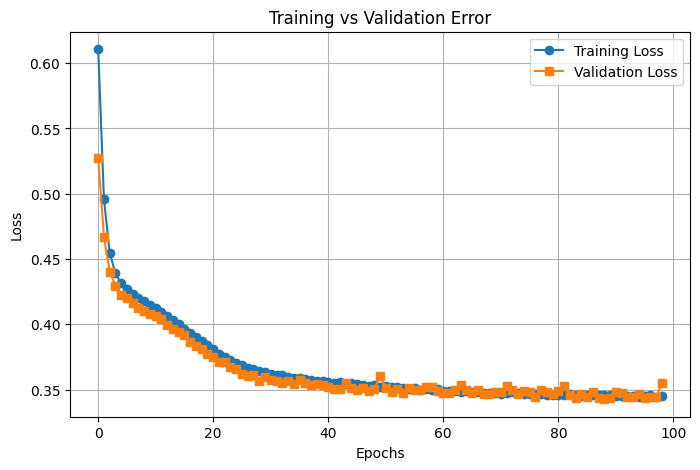

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         marker='o')

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         marker='s')

plt.title("Training vs Validation Error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


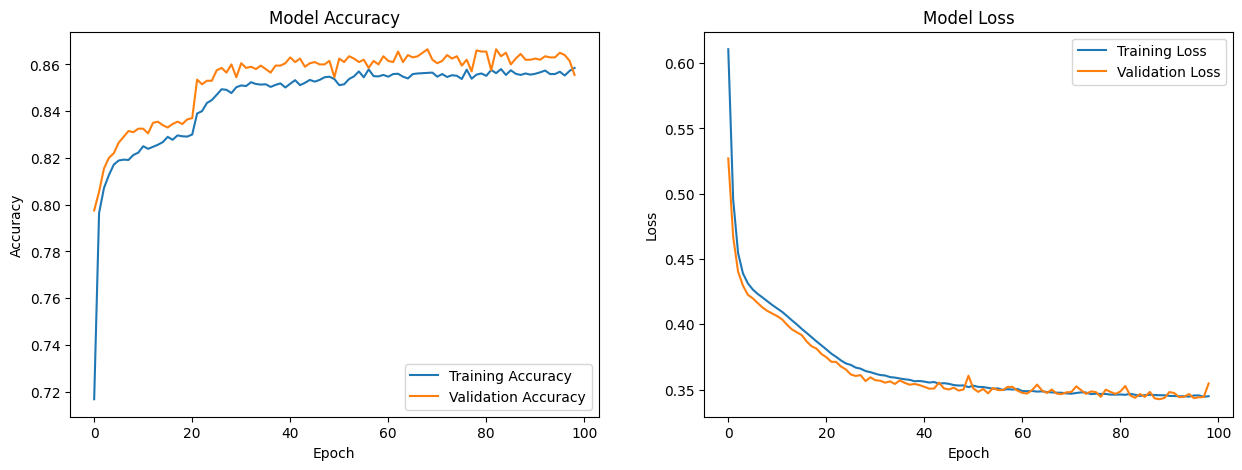

In [21]:
def plot_training_history(history):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

    # Accuracy
    ax1.plot(history.history['accuracy'],
             label='Training Accuracy')

    ax1.plot(history.history['val_accuracy'],
             label='Validation Accuracy')

    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'],
             label='Training Loss')

    ax2.plot(history.history['val_loss'],
             label='Validation Loss')

    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_training_history(history)